<a href="https://colab.research.google.com/github/souzaneh/Fuel-Card/blob/main/fuel_LSTM_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# New Section

#import data & liberaris

In [ ]:
import pandas as pd
# Replace 'D:\data_science\fuel_card_project\sample_data.xlsx' with the actual path
file_path = 'sample_data.xlsx' # Assuming the file is in the default Colab environment

original_normal_df = pd.read_excel(file_path, sheet_name='normal')
original_mixed_df = pd.read_excel(file_path, sheet_name='mixed')


In [ ]:

#path = 'D:\data_science\fuel_card_project\sample_data.xlsx'
normal_df = original_normal_df.copy() # You can also use the sheet index, e.g., sheet_name=0
mixed_df1 = original_mixed_df.copy()
mixed_df = original_mixed_df.drop(['anomaly','anomaly_cat'],axis=1)
list_df = pd.read_excel('sample_data.xlsx', sheet_name='sample1')

normal_df.head() #, mixed_df

,station,VIN,time,fuel,pompNo,amount,plate
0,a,NAB374448LA000882,1402/09/01 06:01:18,نفت گاز,6,200.0,12الف 003
1,a,NAB374448LA000882,1402/09/03 18:05:21,نفت گاز,6,200.0,12الف 003
2,a,NAB374448LA000882,1402/09/10 14:45:31,نفت گاز,6,200.0,12الف 003
3,b,NAB374448LA000882,1402/09/11 19:34:08,نفت گاز,6,200.0,12الف 003
4,a,NAB374448LA000882,1402/09/20 19:05:29,نفت گاز,6,200.0,12الف 003


In [ ]:
normal_df_with_mse_original = original_normal_df.copy()
original_normal_df = normal_df

In [ ]:
mixed_df1

,station,VIN,time,fuel,pompNo,amount,plate,anomaly,anomaly_cat
0,b,IRADX8810BG867727,1402/09/26 09:57:53,بنزین معمولی,1,10.00,12الف 060,1,تكرار
1,b,IRADX8810BG867727,1402/09/26 19:39:02,بنزین معمولی,1,10.00,12الف 060,1,تكرار
2,b,IRADX8810BG867727,1402/09/26 19:41:11,بنزین معمولی,1,10.00,12الف 060,1,تكرار
3,c,IREB9394S7I443394,1402/09/09 13:24:15,نفت گاز,6,150.00,12الف 062,1,تكرار
4,c,IREB9394S7I443394,1402/09/10 19:15:53,نفت گاز,6,150.00,12الف 062,1,تكرار
...,...,...,...,...,...,...,...,...,...
99,a,IRAFC8910A3939844,1402/09/20 12:24:39,بنزین معمولی,1,3.34,12الف 046,1,يك چند
100,b,IRAFC9013LC000559,1402/09/13 17:58:59,بنزین معمولی,4,4.47,12الف 047,1,يك چند
101,b,IRAFC9013LC000559,1402/09/15 16:58:04,بنزین معمولی,1,9.89,12الف 048,1,يك چند
102,b,IRAFC9013LC000559,1402/09/15 20:37:20,بنزین معمولی,4,10.00,12الف 048,1,يك چند


#data prepration

## time column

In [ ]:
!pip install jdatetime

In [ ]:
# conver time column to datetime type

import pandas as pd
import jdatetime
# Function to convert Jalali date string to Gregorian datetime
def convert_jalali_to_datetime(jalali_str):
    # Strip any leading or trailing whitespace
    jalali_str = jalali_str.strip()

    # Split the Jalali date string into date and time
    parts = jalali_str.split(' ')

    # Check if the split resulted in exactly two parts
    if len(parts) != 2:
        print(f"Unexpected format for: '{jalali_str}'")  # Debugging line
        return None  # Or handle the error as needed

    date_part, time_part = parts

    # Split the date part into year, month, and day
    year, month, day = map(int, date_part.split('/'))

    # Convert to Gregorian datetime
    gregorian_date = jdatetime.date(year, month, day).togregorian()

    # Split the time part into hours, minutes, and seconds
    time_parts = time_part.split(':')
    if len(time_parts) != 3:
        print(f"Unexpected time format for: '{time_part}'")  # Debugging line
        return None  # Or handle the error as needed

    hours, minutes, seconds = map(int, time_parts)

    # Combine the Gregorian date with the time part
    return pd.Timestamp(gregorian_date) + pd.Timedelta(hours=hours, minutes=minutes, seconds=seconds)
#print(df)
# Apply the conversion function to the 'time' column
normal_df['time'] = normal_df['time'].apply(convert_jalali_to_datetime)
mixed_df['time'] = mixed_df['time'].apply(convert_jalali_to_datetime)
# Display the DataFrame
#print(df)
print(mixed_df.dtypes)  # Check the data types to confirm the conversion
#print(normal_df.dtypes)  # Check the data types to confirm the conversion

station            object
VIN                object
time       datetime64[ns]
fuel               object
pompNo              int64
amount            float64
plate              object
dtype: object


In [ ]:
normal_df.head()

,station,VIN,time,fuel,pompNo,amount,plate
0,a,NAB374448LA000882,2023-11-22 06:01:18,نفت گاز,6,200.0,12الف 003
1,a,NAB374448LA000882,2023-11-24 18:05:21,نفت گاز,6,200.0,12الف 003
2,a,NAB374448LA000882,2023-12-01 14:45:31,نفت گاز,6,200.0,12الف 003
3,b,NAB374448LA000882,2023-12-02 19:34:08,نفت گاز,6,200.0,12الف 003
4,a,NAB374448LA000882,2023-12-11 19:05:29,نفت گاز,6,200.0,12الف 003


In [ ]:
mixed_df.head()

,station,VIN,time,fuel,pompNo,amount,plate
0,b,IRADX8810BG867727,2023-12-17 09:57:53,بنزین معمولی,1,10.0,12الف 060
1,b,IRADX8810BG867727,2023-12-17 19:39:02,بنزین معمولی,1,10.0,12الف 060
2,b,IRADX8810BG867727,2023-12-17 19:41:11,بنزین معمولی,1,10.0,12الف 060
3,c,IREB9394S7I443394,2023-11-30 13:24:15,نفت گاز,6,150.0,12الف 062
4,c,IREB9394S7I443394,2023-12-01 19:15:53,نفت گاز,6,150.0,12الف 062


## null values, sort

In [ ]:
# Check for any null values in the entire DataFrame
has_nulls = mixed_df.isnull().values.any()
print("Does the DataFrame contain any null values?", has_nulls)

# Method to find rows with any null or NaT
rows_with_nulls = mixed_df[mixed_df.isnull().any(axis=1)]

# Display the rows with null or NaT values
print("Rows with null or NaT values:")
print(rows_with_nulls)

Does the DataFrame contain any null values? False
Rows with null or NaT values:
Empty DataFrame
Columns: [station, VIN, time, fuel, pompNo, amount, plate]
Index: []


In [ ]:
# Sort by VIN and time         # & normalization

normal_df.sort_values(by=['VIN', 'time'], inplace=True)
mixed_df.sort_values(by=['VIN', 'time'], inplace=True)
mixed_df1.sort_values(by=['VIN', 'time'], inplace=True)

#df['day'] = df['time'].dt.day
# Create lagged features
#df['amount_lag1'] = df.groupby('VIN')['amount'].shift(1)

# Normalize numerical columns
#from sklearn.preprocessing import MinMaxScaler
#scaler = MinMaxScaler()
#normal_df['amount'] = scaler.fit_transform(normal_df[['amount']]).round(3)

normal_df.head()

,station,VIN,time,fuel,pompNo,amount,plate
61,b,CNBG14H72DD015898,2023-11-23 19:16:35,نفت گاز,6,150.00,12الف 017
62,b,CNBG14H72DD015898,2023-11-24 16:55:30,نفت گاز,5,150.00,12الف 017
63,b,CNBG14H72DD015898,2023-12-01 17:29:00,نفت گاز,6,90.03,12الف 017
64,b,CNLB077A877011023,2023-12-04 12:55:53,نفت گاز,5,88.47,12الف 018
65,b,CNLB077A877011023,2023-12-06 10:24:53,نفت گاز,6,98.16,12الف 018


# train on normal_df (normal transaction) by  LSTM autoencoder

##steps **

In [ ]:
## import tools

import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from keras.models import Model
from keras.layers import Input, LSTM, RepeatVector, Dense, Embedding, Concatenate
from keras.optimizers import Adam
from sklearn.preprocessing import MinMaxScaler

#  Extract features from the time column
normal_df['hour'] = normal_df['time'].dt.hour
normal_df['day_of_week'] = normal_df['time'].dt.dayofweek
normal_df['month'] = normal_df['time'].dt.month
normal_df.head()

,station,VIN,time,fuel,pompNo,amount,plate,hour,day_of_week,month
61,b,CNBG14H72DD015898,2023-11-23 19:16:35,نفت گاز,6,150.00,12الف 017,19,3,11
62,b,CNBG14H72DD015898,2023-11-24 16:55:30,نفت گاز,5,150.00,12الف 017,16,4,11
63,b,CNBG14H72DD015898,2023-12-01 17:29:00,نفت گاز,6,90.03,12الف 017,17,4,12
64,b,CNLB077A877011023,2023-12-04 12:55:53,نفت گاز,5,88.47,12الف 018,12,0,12
65,b,CNLB077A877011023,2023-12-06 10:24:53,نفت گاز,6,98.16,12الف 018,10,2,12


In [ ]:
# Step 3: Prepare categorical features and numerical features
categorical_features = ['station', 'VIN', 'fuel', 'pompNo', 'plate']
numerical_features = ['hour', 'day_of_week', 'month', 'amount']

# Step 4: Encode categorical features
known_categories ={}
label_encoders = {}
for feature in categorical_features:
    le = LabelEncoder()
    normal_df[feature] = le.fit_transform(normal_df[feature])

   # print (feature,known_categories  )
    label_encoders[feature] = le
    known_categories[feature] = set(le.classes_)

print('known_categories :', known_categories)
#normal_df.head()

known_categories : {'station': {'a', 'c', 'b'}, 'VIN': {'IRBD877AKTP127989', 'IRPC841V03C134509', 'IRAGZ9113RX110628', 'IRAEO9113OX101868', 'IRAE897AUXU870312', 'IRPC871V1IW722631', 'IRABR8810Q9805951', 'IRPC911VXUV030292', 'IRABR9210UD212313', 'IRPC871V1IW897864', 'IRAIW95139A512275', 'CNLB077A877011023', 'DETL789F2SC803801', 'IRPC871V1IW589871', 'IRFC931XIFL407768', 'IRAGZ9113RX110662', 'IRPC871V1IW912097', 'IRGC794Q0NF001231', 'IRAE877A3MG632204', 'IRGC875K51Z600240', 'IRPC871V1IW802900', 'IRNC911X1BL352796', 'NAB374448LA000882', 'IRAE897AUXU870239', 'CNBG14H72DD015898'}, 'fuel': {'نفت گاز', 'بنزین معمولی'}, 'pompNo': {np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)}, 'plate': {'12الف 014', '12الف 090', '12الف 022', '12الف 009', '12الف 092', '12الف 003', '12الف 007', '12الف 093', '12الف 023', '12الف 019', '12الف 017', '12الف 005', '12الف 013', '12الف 012', '12الف 010', '12الف 088', '12الف 021', '12الف 089', '12الف 011', '12الف 006', '12الف 008', '12الف 0

In [ ]:
normal_df.head()

,station,VIN,time,fuel,pompNo,amount,plate,hour,day_of_week,month
61,1,0,2023-11-23 19:16:35,1,5,150.00,12,19,3,11
62,1,0,2023-11-24 16:55:30,1,4,150.00,12,16,4,11
63,1,0,2023-12-01 17:29:00,1,5,90.03,12,17,4,12
64,1,1,2023-12-04 12:55:53,1,4,88.47,13,12,0,12
65,1,1,2023-12-06 10:24:53,1,5,98.16,13,10,2,12


In [ ]:
label_encoders

{'station': LabelEncoder(),
 'VIN': LabelEncoder(),
 'fuel': LabelEncoder(),
 'pompNo': LabelEncoder(),
 'plate': LabelEncoder()}

In [ ]:
# Step 5: Scale numerical features اگر ديتاهاي زمان رو اسكيل نكنم لاس خيلي بالا مي ره   ولي يك نوع اسكيل سينوس و كسينوسي هم هست كه بهتره براي زمان
# Normalize numerical columns
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

X_numerical_normal_scaled = scaler.fit_transform(normal_df[numerical_features])
#print(normal_df)
print ('X_numerical_normal_scaled:',X_numerical_normal_scaled[0].round(3))

X_numerical_normal_scaled: [0.857 0.5   0.909 0.495]


In [ ]:
# Step 6: Prepare categorical features for LSTM
#X_numerical_normal= normal_df[numerical_features].values .round(3)
X_categories_normal = normal_df[categorical_features].values
X_categories_normal
#X_numerical_normal

array([[ 1,  0,  1,  5, 12],
       [ 1,  0,  1,  4, 12],
       [ 1,  0,  1,  5, 12],
       [ 1,  1,  1,  4, 13],
       [ 1,  1,  1,  5, 13],
       [ 1,  1,  1,  4, 13],
       [ 0,  2,  1,  5, 14],
       [ 0,  2,  1,  5, 14],
       [ 0,  2,  1,  5, 14],
       [ 0,  2,  1,  4, 14],
       [ 2,  2,  1,  5, 14],
       [ 0,  2,  1,  5, 14],
       [ 0,  2,  1,  5, 14],
       [ 0,  3,  0,  3,  5],
       [ 0,  3,  0,  3,  5],
       [ 1,  3,  0,  3,  5],
       [ 0,  3,  0,  3,  5],
       [ 1,  3,  0,  3,  5],
       [ 0,  3,  0,  3,  5],
       [ 1,  3,  0,  0,  5],
       [ 0,  3,  0,  0,  5],
       [ 0,  3,  0,  0,  5],
       [ 0,  4,  0,  3,  8],
       [ 0,  4,  0,  3,  8],
       [ 0,  4,  0,  3,  8],
       [ 2,  4,  0,  0,  8],
       [ 1,  5,  1,  5, 15],
       [ 0,  5,  1,  5, 15],
       [ 0,  5,  1,  5, 15],
       [ 0,  5,  1,  5, 15],
       [ 0,  5,  1,  5, 15],
       [ 2,  6,  1,  5, 16],
       [ 0,  6,  1,  5, 16],
       [ 0,  6,  1,  5, 16],
       [ 0,  7

In [ ]:
# Step 7: Reshape Input for LSTM and create sequences for each VIN

sequence_length = 3  # You can adjust this based on your needs
X_numerical_sequences = []
X_categories_sequences = []
normal_sequence_info = [] # Add list to store info to map sequences back to original data

# Fit the scaler on the entire numerical features of normal_df
#scaler = MinMaxScaler()
#normal_df['hour'] = normal_df['time'].dt.hour
#normal_df['day_of_week'] = normal_df['time'].dt.dayofweek
#normal_df['month'] = normal_df['time'].dt.month
#X_numerical_normal_scaled = scaler.fit_transform(normal_df[numerical_features])


# Group data by VIN and create sequences for each VIN separately
for vin, group in normal_df.groupby('VIN'):
    # Ensure group has enough data to create at least one sequence
    if len(group) >= sequence_length:
        # Get the scaled numerical features for the current group
        # We need to get the indices of the group in the original normal_df to get the corresponding scaled data
        indices = group.index
        X_numerical_normal_group = X_numerical_normal_scaled[indices].round(3)
        X_categories_normal_group = group[categorical_features].values

        for i in range(len(group) - sequence_length + 1):
            X_numerical_sequences.append(X_numerical_normal_group[i:i + sequence_length])
            X_categories_sequences.append(X_categories_normal_group[i:i + sequence_length])
            # Store information about the sequence (index of the last transaction)
            normal_sequence_info.append({'original_index': indices[i + sequence_length - 1], 'VIN': vin})
            #print(normal_sequence_info)


X_numerical_sequences = np.array(X_numerical_sequences)
X_categories_sequences = np.array(X_categories_sequences)

print('Shape of numerical sequences:', X_numerical_sequences.shape)
print('Shape of categorical sequences:', X_categories_sequences.shape)
print(normal_sequence_info)

Shape of numerical sequences: (72, 3, 4)
Shape of categorical sequences: (72, 3, 5)
[{'original_index': np.int64(63), 'VIN': 0}, {'original_index': np.int64(66), 'VIN': 1}, {'original_index': np.int64(69), 'VIN': 2}, {'original_index': np.int64(70), 'VIN': 2}, {'original_index': np.int64(71), 'VIN': 2}, {'original_index': np.int64(72), 'VIN': 2}, {'original_index': np.int64(73), 'VIN': 2}, {'original_index': np.int64(31), 'VIN': 3}, {'original_index': np.int64(32), 'VIN': 3}, {'original_index': np.int64(33), 'VIN': 3}, {'original_index': np.int64(34), 'VIN': 3}, {'original_index': np.int64(35), 'VIN': 3}, {'original_index': np.int64(36), 'VIN': 3}, {'original_index': np.int64(37), 'VIN': 3}, {'original_index': np.int64(47), 'VIN': 4}, {'original_index': np.int64(48), 'VIN': 4}, {'original_index': np.int64(76), 'VIN': 5}, {'original_index': np.int64(77), 'VIN': 5}, {'original_index': np.int64(78), 'VIN': 5}, {'original_index': np.int64(81), 'VIN': 6}, {'original_index': np.int64(84), 'V

In [ ]:
# Step 8: Define the LSTM Autoencoder Model
#امبدينگ روابط بين دسته هاي را محاسبه مي كند

# Set up embedding sizes
embedding_sizes = [len(np.unique(normal_df[feature])) for feature in categorical_features]

# Input layers for categorical data
input_categories = Input(shape=(X_categories_sequences.shape[1], X_categories_sequences.shape[2]))  # (sequence_length, num_features)
print('input_categories :' ,input_categories )

# Define embedding layers for each categorical feature
embeddings = []
for i, feature in enumerate(categorical_features):
    embedding = Embedding(input_dim=embedding_sizes[i] , output_dim=8, input_length=sequence_length)(input_categories[:, :, i])
    embeddings.append(embedding)

# Concatenate all embeddings into one tensor
concatenated_embeddings = Concatenate(axis=-1)(embeddings)

# Input layers for numerical data
input_numerical = Input(shape=(X_numerical_sequences.shape[1], X_numerical_sequences.shape[2]))  # (sequence_length, num_features)

# Combine numerical input and concatenated embeddings
combined_input = Concatenate(axis=-1)([input_numerical, concatenated_embeddings])
print('combined_input_shape:',combined_input.shape)
#?? flattened = Flatten()(combin_input)

input_categories : <KerasTensor shape=(None, 3, 5), dtype=float32, sparse=False, ragged=False, name=keras_tensor_14>
combined_input_shape: (None, 3, 44)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [ ]:
embedding_sizes

[3, 25, 2, 6, 25]

In [ ]:
embeddings

[<KerasTensor shape=(None, 3, 8), dtype=float32, sparse=False, ragged=False, name=keras_tensor_2>,
 <KerasTensor shape=(None, 3, 8), dtype=float32, sparse=False, ragged=False, name=keras_tensor_4>,
 <KerasTensor shape=(None, 3, 8), dtype=float32, sparse=False, ragged=False, name=keras_tensor_6>,
 <KerasTensor shape=(None, 3, 8), dtype=float32, sparse=False, ragged=False, name=keras_tensor_8>,
 <KerasTensor shape=(None, 3, 8), dtype=float32, sparse=False, ragged=False, name=keras_tensor_10>]

In [ ]:
concatenated_embeddings

<KerasTensor shape=(None, 3, 40), dtype=float32, sparse=False, ragged=False, name=keras_tensor_11>

In [ ]:
combined_input.shape

(None, 3, 44)

In [ ]:
input_categories

<KerasTensor shape=(None, 3, 5), dtype=float32, sparse=False, ragged=False, name=keras_tensor>

In [ ]:
# Step 8: Define the LSTM Autoencoder Model

# Define the LSTM layers
encoded = LSTM(50, return_sequences=False)(combined_input)
decoded = RepeatVector(X_numerical_sequences.shape[1])(encoded)
decoded = LSTM(50, return_sequences=True)(decoded)

#??? چرا براي لايه خروجي به اندازه فيچر هاي عددي در نظر گرفته شده است؟ به چه معناست ؟
# Output layer
# Adjusting the output layer for anomaly detection
output = Dense(X_numerical_sequences.shape[2], activation='sigmoid')(decoded) # Output layer for binary classification

# Compile the model
model = Model(inputs=[input_numerical, input_categories], outputs=output)
model.compile(optimizer=Adam(), loss='mean_squared_error')  # Binary crossentropy for classification(got error)

# Step 9: Train the model (using the same data for input and output as it's an autoencoder)
model.fit([X_numerical_sequences, X_categories_sequences], X_numerical_sequences, batch_size=32, epochs=100, validation_split=0.2)

Epoch 1/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 9s 839ms/step - loss: 0.1348 - val_loss: 0.1121
Epoch 2/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - loss: 0.1335 - val_loss: 0.1090
Epoch 3/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - loss: 0.1296 - val_loss: 0.1058
Epoch 4/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - loss: 0.1256 - val_loss: 0.1024
Epoch 5/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - loss: 0.1231 - val_loss: 0.0987
Epoch 6/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - loss: 0.1190 - val_loss: 0.0945
Epoch 7/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - loss: 0.1160 - val_loss: 0.0899
Epoch 8/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step - loss: 0.1127 - val_loss: 0.0847
Epoch 9/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - loss: 0.1052 - val_loss: 0.0792
Epoch 10/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - loss: 0.1003 - val_loss: 0.0734
Epoch 11/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - loss: 0.0939 - val_loss: 0.0680
Epoch 12/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - loss: 0.0907 - val_

In [ ]:
# Step 10: Anomaly Detection - Calculate MSE on the training data to determine a threshold
predictions_normal = model.predict([X_numerical_sequences, X_categories_sequences])
mse_normal = np.mean(np.square(predictions_normal - X_numerical_sequences), axis=(1, 2))

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 320ms/step


## in one cell ويرايش نشده

In [ ]:
## train normal_df

import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from keras.models import Model
from keras.layers import Input, LSTM, RepeatVector, Dense, Embedding, Concatenate
from keras.optimizers import Adam
from sklearn.preprocessing import MinMaxScaler

# Step 1: Load your dataset (already done in previous cells, assuming normal_df is available)
# Example: normal_df = pd.read_csv('your_dataset.csv')  # Uncomment and load your actual dataset
# Ensure 'time' is in datetime format if it exists
# normal_df['time'] = pd.to_datetime(normal_df['time'])

# Step 2: Extract features from the time column
normal_df['hour'] = normal_df['time'].dt.hour
normal_df['day_of_week'] = normal_df['time'].dt.dayofweek
normal_df['month'] = normal_df['time'].dt.month

# Step 3: Prepare categorical features and numerical features
categorical_features = ['station', 'VIN', 'fuel', 'pompNo', 'plate']
numerical_features = ['hour', 'day_of_week', 'month', 'amount']

# Step 4: Encode categorical features
known_categories = {}
label_encoders = {}
for feature in categorical_features:
    le = LabelEncoder()
    normal_df[feature] = le.fit_transform(normal_df[feature])

    # print (feature,known_categories  )
    label_encoders[feature] = le
    known_categories[feature] = set(le.classes_)

print('known_categories :', known_categories)

# Step 5: Scale numerical features
scaler = MinMaxScaler()
X_numerical_normal = scaler.fit_transform(normal_df[numerical_features])
#print(normal_df)
#print ('X_numerical_normal:',X_numerical_normal[0])

# Step 6: Prepare categorical features for LSTM
#X_numerical_normal = normal_df[numerical_features].values
X_categories_normal = normal_df[categorical_features].values

# Step 7: Reshape Input for LSTM and create sequences
sequence_length = 3  # You can adjust this based on your needs
X_numerical_sequences = []
X_categories_sequences = []
print('1'),X_categories_normal
for i in range(len(normal_df) - sequence_length):
    X_numerical_sequences.append(X_numerical_normal[i:i + sequence_length])
    X_categories_sequences.append(X_categories_normal[i:i + sequence_length])

X_numerical_sequences = np.array(X_numerical_sequences)
X_categories_sequences = np.array(X_categories_sequences)
print('2'),X_categories_sequences[0]


# Step 8: Define the LSTM Autoencoder Model
# Set up embedding sizes
embedding_sizes = [len(np.unique(normal_df[feature])) for feature in categorical_features]

# Input layers for numerical data
input_numerical = Input(shape=(X_numerical_sequences.shape[1], X_numerical_sequences.shape[2]), name='numerical_input')  # (sequence_length, num_features)

# Input layers for categorical data
input_categories = Input(shape=(X_categories_sequences.shape[1], X_categories_sequences.shape[2]), name='categorical_input')
print('input_categories :' ,input_categories )
# Define embedding layers for each categorical feature
embeddings = []
for i, feature in enumerate(categorical_features):
    embedding = Embedding(input_dim=embedding_sizes[i]  , output_dim=8, input_length=sequence_length, name=f'embedding_{feature}')(input_categories[:, :, i])
    embeddings.append(embedding)

# Concatenate all embeddings into one tensor
concatenated_embeddings = Concatenate(axis=-1, name='concatenated_embeddings')(embeddings)

# Combine numerical input and concatenated embeddings
combined_input = Concatenate(axis=-1, name='combined_input')([input_numerical, concatenated_embeddings])
print('combined_input_shape:',combined_input.shape)


# Define the LSTM layers
encoded = LSTM(50, activation='relu', return_sequences=False, name='encoder_lstm')(combined_input)
decoded = RepeatVector(X_numerical_sequences.shape[1], name='repeat_vector')(encoded)
decoded = LSTM(50, activation='relu', return_sequences=True, name='decoder_lstm')(decoded)

# Output layer
# Adjusting the output layer to reconstruct the numerical features
output = Dense(X_numerical_sequences.shape[2], activation='sigmoid', name='output_dense')(decoded)

# Compile the model
model = Model(inputs=[input_numerical, input_categories], outputs=output)
model.compile(optimizer=Adam(), loss='mean_squared_error')

# Step 9: Train the model (using the same data for input and output as it's an autoencoder)
history = model.fit([X_numerical_sequences, X_categories_sequences], X_numerical_sequences, batch_size=32, epochs=100, validation_split=0.2)

# Step 10: Anomaly Detection - Calculate MSE on the training data to determine a threshold
predictions_normal = model.predict([X_numerical_sequences, X_categories_sequences])
mse_normal = np.mean(np.square(predictions_normal - X_numerical_sequences), axis=(1, 2))

known_categories : {'station': {'b', 'c', 'a'}, 'VIN': {'IRBD877AKTP127989', 'IRPC911VXUV030292', 'IRPC871V1IW897864', 'IRAIW95139A512275', 'IRPC871V1IW802900', 'IRAE897AUXU870239', 'CNLB077A877011023', 'IRAE877A3MG632204', 'IRAEO9113OX101868', 'DETL789F2SC803801', 'IRAGZ9113RX110628', 'IRAE897AUXU870312', 'IRAGZ9113RX110662', 'IRFC931XIFL407768', 'IRGC794Q0NF001231', 'IRPC871V1IW722631', 'NAB374448LA000882', 'IRPC871V1IW589871', 'IRABR9210UD212313', 'CNBG14H72DD015898', 'IRABR8810Q9805951', 'IRGC875K51Z600240', 'IRPC871V1IW912097', 'IRPC841V03C134509', 'IRNC911X1BL352796'}, 'fuel': {'بنزین معمولی', 'نفت گاز'}, 'pompNo': {np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)}, 'plate': {'12الف 003', '12الف 017', '12الف 090', '12الف 010', '12الف 013', '12الف 011', '12الف 022', '12الف 020', '12الف 009', '12الف 018', '12الف 008', '12الف 015', '12الف 088', '12الف 014', '12الف 089', '12الف 023', '12الف 007', '12الف 093', '12الف 091', '12الف 006', '12الف 092', '12الف 0

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 248ms/step - loss: 0.1306 - val_loss: 0.1319
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.1299 - val_loss: 0.1299
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.1272 - val_loss: 0.1279
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.1250 - val_loss: 0.1255
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.1240 - val_loss: 0.1226
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.1195 - val_loss: 0.1191
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 0.1167 - val_loss: 0.1146
Epoch 8/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.1152 - val_loss: 0.1087
Epoch 9/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.1082 - val_loss: 0.1009
Epoch 10/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 0.1033 - val_loss: 0.0906
Epoch 11/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.0912 - val_loss: 0.0782
Epoch 12/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.0828 - val_loss: 0.0656


## predict, mse_normal, evaluate model

In [ ]:
max_mse_per_index_normal = {}

# Check if normal_sequence_info is defined, if not, recreate it
if 'normal_sequence_info' not in locals() and 'normal_sequence_info' not in globals():
    print("Recreating normal_sequence_info...")
    normal_sequence_info = []
    # Assuming normal_df, numerical_features, categorical_features, and sequence_length are already defined
    # and normal_df has been processed (time features extracted, categories encoded)

    # Group data by VIN and create sequences for each VIN separately
    for vin, group in normal_df.groupby('VIN'):
        if len(group) >= sequence_length:
            indices = group.index
            for i in range(len(group) - sequence_length + 1):
                normal_sequence_info.append({'original_index': indices[i + sequence_length - 1], 'VIN': vin})
    print("normal_sequence_info recreated.")

for i, info in enumerate(normal_sequence_info):
    original_index = info['original_index']
    mse_value = mse_normal[i]
    if original_index not in max_mse_per_index_normal or mse_value > max_mse_per_index_normal[original_index]:
        max_mse_per_index_normal[original_index] = mse_value

print("max_mse_per_index_normal has been created.")

max_mse_per_index_normal has been created.


In [ ]:

# A safer approach is to re-map mse_normal to the reloaded and sorted dataframe
# First, create a temporary DataFrame with original indices and mse_normal from the processed data
mse_temp_df = pd.DataFrame.from_dict(max_mse_per_index_normal, orient='index', columns=['mse_normal'])
mse_temp_df.index.name = 'original_index'

# Reset index of the reloaded dataframe to merge on original index
normal_df_with_mse_original = original_normal_df.reset_index().rename(columns={'index': 'original_index'})

# Merge the mse_normal based on the original index
normal_df_with_mse_original = pd.merge(normal_df_with_mse_original, mse_temp_df, on='original_index', how='left')

# Set the original index back if desired
normal_df_with_mse_original.set_index('original_index', inplace=True)
normal_df_with_mse_original.sort_index(inplace=True) # Sort by original index


print("Normal DataFrame with original categorical values and MSE:")
#display(normal_df_with_mse_original.sort_values(by=['mse_normal'],ascending=False))
display(normal_df_with_mse_original)

Normal DataFrame with original categorical values and MSE:


,station,VIN,time,fuel,pompNo,amount,plate,mse_normal
original_index,,,,,,,,
0,a,NAB374448LA000882,1402/09/01 06:01:18,نفت گاز,6,200.00,12الف 003,NaN
1,a,NAB374448LA000882,1402/09/03 18:05:21,نفت گاز,6,200.00,12الف 003,NaN
2,a,NAB374448LA000882,1402/09/10 14:45:31,نفت گاز,6,200.00,12الف 003,0.042581
3,b,NAB374448LA000882,1402/09/11 19:34:08,نفت گاز,6,200.00,12الف 003,0.059395
4,a,NAB374448LA000882,1402/09/20 19:05:29,نفت گاز,6,200.00,12الف 003,0.050503
...,...,...,...,...,...,...,...,...
117,a,IRPC871V1IW912097,1402/09/15 14:32:37,بنزین معمولی,4,12.67,12الف 093,0.044052
118,a,IRPC871V1IW912097,1402/09/16 04:14:14,بنزین معمولی,1,14.67,12الف 093,0.046788
119,c,IRPC871V1IW912097,1402/09/17 10:50:53,بنزین معمولی,4,8.90,12الف 093,0.026132


In [ ]:
#evaluate the model on normal_df

import numpy as np

# Calculate MSE for normal data if not already available
if 'predictions_normal' not in locals():
    print("Calculating predictions for normal data...")
    # Assuming X_numerical_sequences and X_categories_sequences from normal_df are available
    predictions_normal = model.predict([X_numerical_sequences, X_categories_sequences])
    mse_normal = np.mean(np.square(predictions_normal - X_numerical_sequences), axis=(1, 2))


# Calculate and print the mean and standard deviation of the MSE for normal data
mean_mse_normal = np.mean(mse_normal)
std_mse_normal = np.std(mse_normal)

print(f"Mean MSE for normal data: {mean_mse_normal:.4f}")
print(f"Standard Deviation of MSE for normal data: {std_mse_normal:.4f}")

Mean MSE for normal data: 0.0336
Standard Deviation of MSE for normal data: 0.0236


# prepare and predict mixed_df (contain anomaly transaction) for testing the model

## in one cell **

In [ ]:
##prepare mixed_df

import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import MinMaxScaler


# Step 2: Extract features from the time column and convert to integer
mixed_df['hour'] = mixed_df['time'].dt.hour.astype(int)
mixed_df['day_of_week'] = mixed_df['time'].dt.dayofweek.astype(int)
mixed_df['month'] = mixed_df['time'].dt.month.astype(int)


# Step 3: Prepare categorical features and numerical features (should be consistent with training)
categorical_features = ['station', 'VIN', 'fuel', 'pompNo', 'plate']
numerical_features = ['hour', 'day_of_week', 'month', 'amount'] # Ensure this matches the features used for training

# Step 4: Encode categorical features using the same encoders fitted on normal_df
# We need to use the label_encoders fitted on normal_df to ensure consistent encoding
# Handle potential new categories in mixed_df by assigning them to a default value or handling them
mixed_categories = {}
X_categories_mixed_encoded = mixed_df[categorical_features].copy() # Create a copy to avoid SettingWithCopyWarning

for feature in categorical_features:
    if feature in label_encoders:
        le = label_encoders[feature]
        # Use transform if the encoder is already fitted
        # Handle unseen labels in mixed_df by assigning them to a value outside of known categories
        # A common practice is to use the number of known classes as the encoding for unknown
        # Ensure that the categories in mixed_df are within the categories seen during training
        # If not, replace them with a placeholder or handle appropriately.
        # For simplicity here, we'll replace unseen categories with the first category from training.
        train_classes = le.classes_
        mixed_df[feature] = mixed_df[feature].apply(lambda x: x if x in train_classes else train_classes[0])
        mixed_df[feature] = le.transform(mixed_df[feature])
    else:
        # If an encoder for a feature doesn't exist (shouldn't happen if features are consistent),
        # fit a new one (though ideally, all encoders should come from training data)
        le = LabelEncoder()
        mixed_df[feature] = le.fit_transform(mixed_df[feature])
        label_encoders[feature] = le # Store the new encoder

    mixed_categories[feature] = set(mixed_df[feature].unique())


# Step 5: Scale numerical features using the same scaler fitted on normal_df
# Ensure the scaler is the one fitted on X_numerical_normal
X_numerical_mixed_scaled = scaler.transform(mixed_df[numerical_features]).round(3)


# Step 6 & 7: Prepare categorical features for LSTM and create sequences per VIN
sequence_length = 3  # Set your desired sequence length (must be same as training)
X_numerical_sequences_mixed = []
X_categories_sequences_mixed = []
mixed_sequence_info = [] # Store info to map sequences back to original data

for vin, group in mixed_df.groupby('VIN'):
    if len(group) >= sequence_length:
        # Get the scaled numerical and encoded categorical features for the current group
        # Use .loc to ensure we get the data based on the group's original index
        indices = group.index
        X_numerical_mixed_group_scaled = X_numerical_mixed_scaled[indices]
        X_categories_mixed_group_encoded = mixed_df.loc[indices, categorical_features].values

        for i in range(len(group) - sequence_length + 1):
            X_numerical_sequences_mixed.append(X_numerical_mixed_group_scaled[i:i + sequence_length])
            X_categories_sequences_mixed.append(X_categories_mixed_group_encoded[i:i + sequence_length])
            # Store information about the sequence (index of the last transaction)
            mixed_sequence_info.append({'original_index': indices[i + sequence_length - 1], 'VIN': vin})


# Convert lists to numpy arrays
X_numerical_sequences_mixed = np.array(X_numerical_sequences_mixed)
X_categories_sequences_mixed = np.array(X_categories_sequences_mixed)


print('Shape of mixed numerical sequences:', X_numerical_sequences_mixed.shape)
print('Shape of mixed categorical sequences:', X_categories_sequences_mixed.shape)


# threshhold (assuming it's already calculated from normal data)
threshold = np.percentile(mse_normal, 99) # Ensure this is calculated from your normal data MSE

# Step 8: Perform prediction using the trained model
# Ensure the model variable is available from the training steps
if 'model' in locals():
    predictions_mixed = model.predict([X_numerical_sequences_mixed, X_categories_sequences_mixed])

    # Add print statements to inspect predictions and input numerical data
    print("\nFirst few prediction sequences (numerical):")
    print(predictions_mixed[:2])
    print("\nFirst few input numerical sequences:")
    print(X_numerical_sequences_mixed[:2])


    # Step 9: Calculate Mean Squared Error for each sequence
    mse_mixed_sequences = np.mean(np.square(predictions_mixed - X_numerical_sequences_mixed), axis=(1, 2))

    # Map MSE back to original DataFrame using mixed_sequence_info
    # Create a dictionary to store max MSE per original index
    max_mse_per_index = {}
    for i, info in enumerate(mixed_sequence_info):
        original_index = info['original_index']
        mse_value = mse_mixed_sequences[i]
        if original_index not in max_mse_per_index or mse_value > max_mse_per_index[original_index]:
             max_mse_per_index[original_index] = mse_value


    # Add MSE values to mixed_df1 based on the original index
    # Ensure mixed_df1 has all original indices
    mixed_df1['mse'] = 0.0 # Initialize MSE column with default value 0.0
    # Use .loc to safely assign values based on index
    for index, mse_value in max_mse_per_index.items():
        if index in mixed_df1.index:
           mixed_df1.loc[index, 'mse'] = mse_value
        else:
           print(f"Warning: Index {index} from mixed_sequence_info not found in mixed_df1.index")


    # Step 10: Anomaly Detection - Define a threshold and identify anomalies
    # Use the threshold calculated from the normal data MSE
    if 'threshold' in locals():
        # Identify anomalous transactions based on the threshold
        mixed_df1['predicted_anomaly'] = mixed_df1['mse'] > threshold

        # Step 11: Identify anomalous VINs
        # A simple approach: Mark a VIN as anomalous if at least one of its transactions is predicted as anomalous
        anomalous_vins = mixed_df1[mixed_df1['predicted_anomaly']]['VIN'].unique()
        mixed_df1['predicted_anomaly_VIN'] = mixed_df1['VIN'].isin(anomalous_vins)


        print("\nMixed data processed and predictions made.")
        # You can now inspect mixed_df1 to see the 'predicted_anomaly' and 'predicted_anomaly_VIN' columns
    else:
        print("\nThreshold from normal data not found. Please run the training and threshold calculation steps first.")

else:
    print("\nTrained model not found. Please run the model training step first.")

Shape of mixed numerical sequences: (98, 3, 4)
Shape of mixed categorical sequences: (98, 3, 5)
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 

First few prediction sequences (numerical):
[[[0.5251468  0.49562216 0.9604188  0.08810766]
  [0.55828387 0.47856054 0.9913009  0.0311227 ]
  [0.5891443  0.46447593 0.99434155 0.01952208]]

 [[0.5677988  0.5464702  0.95746845 0.0821875 ]
  [0.6255243  0.5508199  0.99003893 0.02676799]
  [0.6591747  0.52625316 0.9934055  0.01674251]]]

First few input numerical sequences:
[[[0.571 0.333 0.909 0.018]
  [0.714 0.    1.    0.023]
  [0.81  0.5   1.    0.029]]

 [[0.714 0.    1.    0.023]
  [0.81  0.5   1.    0.029]
  [0.762 0.667 1.    0.031]]]

Mixed data processed and predictions made.


In [ ]:
# Filter the DataFrame to show only VINs predicted as anomalous
anomalous_vins_df = mixed_df1[mixed_df1['predicted_anomaly_VIN'] == True]

# Filter the DataFrame to show only VINs predicted as normal
normal_vins_df = mixed_df1[mixed_df1['predicted_anomaly_VIN'] == False]

mixed_df1.shape, anomalous_vins_df.shape , normal_vins_df.shape

((104, 12), (5, 12), (99, 12))

## steps -

In [ ]:
##prepare mixed_df

import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# Step 2: Extract features from the time column
mixed_df['hour'] = mixed_df['time'].dt.hour
mixed_df['day_of_week'] = mixed_df['time'].dt.dayofweek
mixed_df['month'] = mixed_df['time'].dt.month

# Step 3: Prepare categorical features and numerical features
categorical_features = ['station', 'VIN', 'fuel', 'pompNo', 'plate']
numerical_features = ['hour', 'day_of_week', 'month', 'amount']

# Step 1: Prepare the mixed dataset
mixed_categories ={}
label_encoders = {}
for feature in categorical_features:
    le = LabelEncoder()
    # Fit and transform on mixed_df; ensure it has the same categories as normal_df
    mixed_df[feature] = le.fit_transform(mixed_df[feature])
    label_encoders[feature] = le  # Store the encoder for potential reuse

    mixed_categories[feature] = set(le.classes_)
  #  print( '***',feature,mixed_categories  )
print('mixed_categories :', mixed_categories)
mixed_df.head()

mixed_categories : {'station': {'a', 'b', 'c'}, 'VIN': {'DETL789F2SC803801', 'IRFC881XIFL093556', 'IRFC881XIFL068724', 'IRFC881XIFL072294', 'IRAFC8910A3939844', 'IRAFC9013LC000559', 'IRAET9510EQ513037', 'IRADX8810BG867727', 'IRGC794Q0NF001231', 'IRFC881XIFL090526', 'BYZL775K0PC021090', 'IRAET96445ND02295', 'IREB9394S7I443394', 'IRGC795K51Z585722', 'IRFC891XIFL137516', 'IRAET9510EQ516247', 'NAS841100N3406441', 'IRFC891VTPE611383', 'IRFC891VPEY262083', 'IRGC564Q328283474', 'IRGC568F1MM262915', 'CNBG14H72DD015898'}, 'fuel': {'نفت گاز', 'بنزین معمولی'}, 'pompNo': {np.int64(1), np.int64(2), np.int64(4), np.int64(5), np.int64(6)}, 'plate': {'12الف 084', '12الف 060', '12الف 037', '12الف 028', '12الف 039', '12الف 070', '12الف 033', '12الف 051', '12الف 038', '12الف 050', '12الف 061', '12الف 048', '12الف 049', '12الف 035', '12الف 032', '12الف 026', '12الف 062', '12الف 030', '12الف 042', '12الف 043', '12الف 047', '12الف 044', '12الف 063', '12الف 056', '12الف 045', '12الف 046', '12الف 024', '12الف

,station,VIN,time,fuel,pompNo,amount,plate,hour,day_of_week,month
59,0,0,2023-11-25 10:28:30,1,4,88.83,20,10,5,11
60,0,0,2023-12-03 07:13:39,1,4,166.17,21,7,6,12
61,0,0,2023-12-11 17:29:15,1,3,166.71,22,17,0,12
62,0,0,2023-12-17 07:27:51,1,4,200.00,21,7,6,12
63,0,1,2023-11-23 19:16:35,1,4,150.00,21,19,3,11


In [ ]:
# normalization
scaler = MinMaxScaler()
X_numerical_normal = scaler.fit_transform(normal_df[numerical_features])
#print(normal_df)
print ('X_numerical_normal:',X_numerical_normal[0])

In [ ]:
# Prepare input features for the LSTM
sequence_length = 3  # Set your desired sequence length
num_samples_mixed = len(mixed_df) - sequence_length

X_categories_mixed = []
X_numerical_mixed = []
VINs = []

for i in range(num_samples_mixed):
    try:
        # Create sequences for categorical features
        X_categories_mixed.append(mixed_df[[f"{feature}" for feature in categorical_features]].iloc[i:i + sequence_length].values)
        # Get the numerical values for the same sequence (assuming 'amount' column exists)
        X_numerical_mixed.append(mixed_df[[f"{feature}" for feature in numerical_features]].iloc[i:i + sequence_length].values)
        VINs.append(mixed_df['VIN'].iloc[i])  # Store the VIN for later reference
    except KeyError as e:
        print(f"KeyError: {e}. Verify that mixed_df contains the required columns.")

# Convert lists to numpy arrays
X_categories_mixed = np.array(X_categories_mixed)  # Shape: (num_samples, sequence_length, num_categorical_features)
X_numerical_mixed = np.array(X_numerical_mixed)  # Shape: (num_samples, sequence_length, 1)
VINs = np.array(VINs)  # Shape: (num_samples,)

model_input = [X_numerical_mixed,X_categories_mixed]

In [ ]:
X_categories_mixed .shape
X_numerical_mixed.shape
VINs
model_input

[array([[[ 10.  ,   5.  ,  11.  ,  88.83],
         [  7.  ,   6.  ,  12.  , 166.17],
         [ 17.  ,   0.  ,  12.  , 166.71]],
 
        [[  7.  ,   6.  ,  12.  , 166.17],
         [ 17.  ,   0.  ,  12.  , 166.71],
         [  7.  ,   6.  ,  12.  , 200.  ]],
 
        [[ 17.  ,   0.  ,  12.  , 166.71],
         [  7.  ,   6.  ,  12.  , 200.  ],
         [ 19.  ,   3.  ,  11.  , 150.  ]],
 
        ...,
 
        [[ 16.  ,   6.  ,  12.  , 190.18],
         [  8.  ,   0.  ,  11.  ,  20.28],
         [  9.  ,   0.  ,  11.  ,  39.62]],
 
        [[  8.  ,   0.  ,  11.  ,  20.28],
         [  9.  ,   0.  ,  11.  ,  39.62],
         [ 10.  ,   0.  ,  11.  ,  29.77]],
 
        [[  9.  ,   0.  ,  11.  ,  39.62],
         [ 10.  ,   0.  ,  11.  ,  29.77],
         [ 16.  ,   6.  ,  12.  ,   8.  ]]]),
 array([[[ 0,  0,  1,  4, 20],
         [ 0,  0,  1,  4, 21],
         [ 0,  0,  1,  3, 22]],
 
        [[ 0,  0,  1,  4, 21],
         [ 0,  0,  1,  3, 22],
         [ 0,  0,  1,  4, 21]],
 
 

In [ ]:
predictions = model.predict(model_input)

NameError: name 'model' is not defined

## evaluate mse_mixed_df & plot **

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

# Ensure both columns are boolean type for comparison
actual_anomalies = mixed_df1['anomaly'].astype(bool)
predicted_anomalies = mixed_df1['predicted_anomaly'].astype(bool)

# Align the lengths if they are different due to sequence creation
min_len = min(len(actual_anomalies), len(predicted_anomalies))
actual_anomalies = actual_anomalies[:min_len]
predicted_anomalies = predicted_anomalies[:min_len]

print("\nConfusion Matrix:")
print(confusion_matrix(actual_anomalies, predicted_anomalies))

print("\nClassification Report:")
print(classification_report(actual_anomalies, predicted_anomalies))


Confusion Matrix:
[[25  1]
 [77  1]]

Classification Report:
              precision    recall  f1-score   support

       False       0.25      0.96      0.39        26
        True       0.50      0.01      0.03        78

    accuracy                           0.25       104
   macro avg       0.37      0.49      0.21       104
weighted avg       0.44      0.25      0.12       104



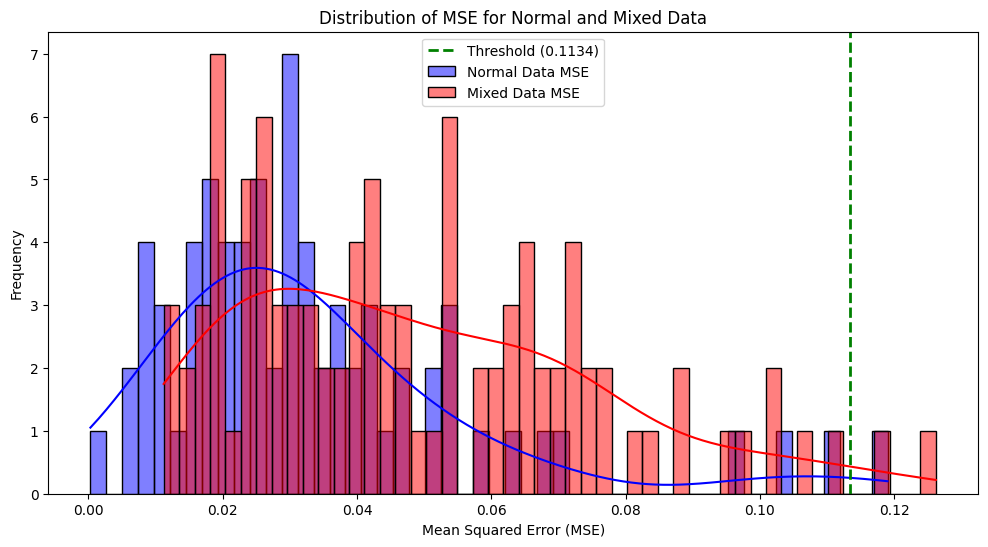

Current anomaly threshold: 0.11335806963446651
Maximum MSE in mixed_df: 0.1261884804285145


In [ ]:
# Plot the distribution of MSE for normal and mixed data
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.histplot(mse_normal, bins=50, kde=True, color='blue', label='Normal Data MSE')
sns.histplot(mse_mixed_sequences, bins=50, kde=True, color='red', label='Mixed Data MSE')
plt.axvline(threshold, color='green', linestyle='dashed', linewidth=2, label=f'Threshold ({threshold:.4f})')
plt.xlabel('Mean Squared Error (MSE)')
plt.ylabel('Frequency')
plt.title('Distribution of MSE for Normal and Mixed Data')
plt.legend()
plt.show()

print(f"Current anomaly threshold: {threshold}")
print(f"Maximum MSE in mixed_df: {np.max(mse_mixed_sequences)}")

## supervised learning _lstm

In [ ]:
# Create a copy of mixed_df1 and name it original_mixed_df_RE
original_mixed_df_RE = mixed_df1.copy()

print("Created original_mixed_df_RE DataFrame:")
display(original_mixed_df_RE.head())

Created original_mixed_df_RE DataFrame:


,station,VIN,time,fuel,pompNo,amount,plate,anomaly,anomaly_cat,mse,predicted_anomaly,predicted_anomaly_VIN
64,a,BYZL775K0PC021090,1402/09/04 10:28:30,نفت گاز,6,88.83,12الف 049,1,يك چند,0.000000,False,False
65,a,BYZL775K0PC021090,1402/09/12 07:13:39,نفت گاز,6,166.17,12الف 050,1,يك چند,0.000000,False,False
66,a,BYZL775K0PC021090,1402/09/20 17:29:15,نفت گاز,5,166.71,12الف 051,1,يك چند,0.028306,False,False
67,a,BYZL775K0PC021090,1402/09/26 07:27:51,نفت گاز,6,200.00,12الف 050,1,يك چند,0.032722,False,False
68,a,CNBG14H72DD015898,1402/09/02 19:16:35,نفت گاز,6,150.00,12الف 050,1,يك چند,0.015944,False,False


In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Embedding, TimeDistributed, concatenate, Input
from tensorflow.keras.models import Model
import tensorflow as tf

# Assuming 'original_mixed_df_RE' is available and contains 'anomaly' and 'mse' columns

# Prepare categorical and numerical features
# Include 'mse' as a numerical feature
categorical_features = ['station', 'VIN', 'fuel', 'pompNo', 'plate']
numerical_features = ['hour', 'day_of_week', 'month', 'amount', 'mse'] # Added 'mse'

# Ensure 'time' column is in datetime format and extract time features if not already done
if not pd.api.types.is_datetime64_any_dtype(original_mixed_df_RE['time']):
     # Assuming convert_jalali_to_datetime function is available from earlier cells
     original_mixed_df_RE['time'] = original_mixed_df_RE['time'].apply(convert_jalali_to_datetime)

original_mixed_df_RE['hour'] = original_mixed_df_RE['time'].dt.hour.astype(int)
original_mixed_df_RE['day_of_week'] = original_mixed_df_RE['time'].dt.dayofweek.astype(int)
original_mixed_df_RE['month'] = original_mixed_df_RE['time'].dt.month.astype(int)

# Encode categorical features
# Fit new encoders on original_mixed_df_RE as it's the training data for the supervised model
label_encoders_supervised = {}
for feature in categorical_features:
    le = LabelEncoder()
    original_mixed_df_RE[feature] = le.fit_transform(original_mixed_df_RE[feature])
    label_encoders_supervised[feature] = le

# Scale numerical features
# Fit a new scaler on the numerical features of original_mixed_df_RE
scaler_supervised = MinMaxScaler()
original_mixed_df_RE[numerical_features] = scaler_supervised.fit_transform(original_mixed_df_RE[numerical_features])

# Create sequences of transactions for supervised learning
sequence_length = 3 # Same sequence length as before

X_numerical_sequences_sup = []
X_categories_sequences_sup = []
y_sequences_sup = [] # Target variable for the sequence (anomaly label)

# Group by VIN and create sequences
for vin, group in original_mixed_df_RE.groupby('VIN'):
    if len(group) >= sequence_length:
        X_numerical_group = group[numerical_features].values
        X_categories_group = group[categorical_features].values
        y_group = group['anomaly'].values # Assuming 'anomaly' is the target column

        for i in range(len(group) - sequence_length + 1):
            X_numerical_sequences_sup.append(X_numerical_group[i:i + sequence_length])
            X_categories_sequences_sup.append(X_categories_group[i:i + sequence_length])
            # The target for a sequence is the anomaly label of the last transaction in the sequence
            y_sequences_sup.append(y_group[i + sequence_length - 1])

X_numerical_sequences_sup = np.array(X_numerical_sequences_sup)
X_categories_sequences_sup = np.array(X_categories_sequences_sup)
y_sequences_sup = np.array(y_sequences_sup)

# Ensure the target variable y is in the correct format (e.g., one-hot encoded if more than 2 classes)
# Assuming 'anomaly' is binary (0 or 1), no further encoding is needed for y.
# Convert y to float32 as required by binary_crossentropy loss
y_sequences_sup = y_sequences_sup.astype(np.float32)


print("Shape of numerical sequences for supervised learning:", X_numerical_sequences_sup.shape)
print("Shape of categorical sequences for supervised learning:", X_categories_sequences_sup.shape)
print("Shape of target labels for supervised learning:", y_sequences_sup.shape)


# Split data into training and testing sets
# Stratify on y to maintain the proportion of anomaly classes in train and test sets
X_numerical_train, X_numerical_test, X_categories_train, X_categories_test, y_train, y_test = train_test_split(
    X_numerical_sequences_sup, X_categories_sequences_sup, y_sequences_sup, test_size=0.2, random_state=42, stratify=y_sequences_sup
)

print("\nTraining data shapes:")
print("X_numerical_train:", X_numerical_train.shape)
print("X_categories_train:", X_categories_train.shape)
print("y_train:", y_train.shape)

print("\nTesting data shapes:")
print("X_numerical_test:", X_numerical_test.shape)
print("X_categories_test:", X_categories_test.shape)
print("y_test:", y_test.shape)


# Define the Supervised LSTM Model
# Adjust input shapes based on the number of numerical features (including mse)
embedding_sizes_supervised = [len(original_mixed_df_RE[feature].unique()) for feature in categorical_features]

# Input layers
input_numerical_sup = Input(shape=(sequence_length, len(numerical_features)), name='numerical_input_sup')
input_categories_sup = Input(shape=(sequence_length, len(categorical_features)), name='categorical_input_sup')

# Embedding layers
embeddings_sup = []
for i, feature in enumerate(categorical_features):
    # Use the size of unique categories in the current DataFrame
    embedding_sup = Embedding(input_dim=embedding_sizes_supervised[i], output_dim=8, input_length=sequence_length, name=f'embedding_sup_{feature}')(input_categories_sup[:, :, i])
    embeddings_sup.append(embedding_sup)

# Concatenate embeddings
concatenated_embeddings_sup = concatenate(embeddings_sup, axis=-1, name='concatenated_embeddings_sup')

# Combine numerical and categorical inputs
combined_input_sup = concatenate([input_numerical_sup, concatenated_embeddings_sup], axis=-1, name='combined_input_sup')

# LSTM layers
lstm_out = LSTM(50, activation='relu', name='lstm_layer')(combined_input_sup)

# Output layer for binary classification (anomaly or normal)
output_sup = Dense(1, activation='sigmoid', name='output_layer_sup')(lstm_out)

# Define the model
supervised_model = Model(inputs=[input_numerical_sup, input_categories_sup], outputs=output_sup)

# Compile the model
supervised_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train the model
print("\nTraining the supervised LSTM model...")
history_sup = supervised_model.fit(
    [X_numerical_train, X_categories_train], y_train,
    epochs=50, # You can adjust the number of epochs
    batch_size=32,
    validation_split=0.2 # Use a validation split from the training data
)

print("\nSupervised LSTM model training complete.")

Shape of numerical sequences for supervised learning: (60, 3, 5)
Shape of categorical sequences for supervised learning: (60, 3, 5)
Shape of target labels for supervised learning: (60,)

Training data shapes:
X_numerical_train: (48, 3, 5)
X_categories_train: (48, 3, 5)
y_train: (48,)

Testing data shapes:
X_numerical_test: (12, 3, 5)
X_categories_test: (12, 3, 5)
y_test: (12,)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(



Training the supervised LSTM model...
Epoch 1/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - accuracy: 0.1118 - loss: 0.7492 - val_accuracy: 0.4000 - val_loss: 0.7060
Epoch 2/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 390ms/step - accuracy: 0.1573 - loss: 0.7313 - val_accuracy: 0.4000 - val_loss: 0.6998
Epoch 3/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 376ms/step - accuracy: 0.1469 - loss: 0.7166 - val_accuracy: 0.6000 - val_loss: 0.6941
Epoch 4/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 327ms/step - accuracy: 0.3531 - loss: 0.7002 - val_accuracy: 0.6000 - val_loss: 0.6886
Epoch 5/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 250ms/step - accuracy: 0.5351 - loss: 0.6864 - val_accuracy: 0.5000 - val_loss: 0.6834
Epoch 6/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 267ms/step - accuracy: 0.8147 - loss: 0.6719 - val_accuracy: 0.6000 - val_loss: 0.6783
Epoch 7/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 253ms/step - accuracy: 0.8882 - loss: 0.6572 - val_accuracy: 0.6000 - val_loss: 0.6734
Epoch 8/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 245ms/step - accuracy: 0.8986 - loss: 0.64

# New Section

# Task
The user wants to enhance the anomaly detection model by converting the current single-output LSTM autoencoder into a multi-output autoencoder. This new model will reconstruct both numerical and categorical features simultaneously.

Here's a breakdown of the steps the agent will perform:

1.  **Modify Autoencoder for Multi-Output Reconstruction**:
    *   The existing LSTM autoencoder model will be updated to include multiple output layers.
    *   One output layer will handle the reconstruction of numerical features, using `TimeDistributed(Dense(...))` with a sigmoid activation and `mean_squared_error` loss.
    *   Separate output layers will be added for each categorical feature. These will also use `TimeDistributed(Dense(...))` with a `softmax` activation and `sparse_categorical_crossentropy` loss.
    *   Embedding layers for categorical inputs will remain in place, feeding into the shared encoder-decoder structure.

2.  **Prepare Multi-Output Target Data**:
    *   The target data (`y` for `model.fit`) will be restructured to be a list, matching the new multi-output layers. This list will contain the `X_numerical_sequences` for the numerical output and slices of `X_categories_sequences` (`X_categories_sequences[:, :, i]`) for each categorical output.

3.  **Train Multi-Output Autoencoder**:
    *   The `multi_output_model` will be compiled with a dictionary of loss functions (MSE for numerical, sparse categorical cross-entropy for each categorical output) and a corresponding dictionary of `loss_weights` to balance their contributions during training.
    *   The model will then be trained using the prepared multi-output target data.

4.  **Calculate Combined Reconstruction Error (Normal Data)**:
    *   After training, the model will predict on the normal dataset, yielding a list of predictions for each output head.
    *   Individual reconstruction errors will be calculated: Mean Squared Error for numerical features and average `sparse_categorical_crossentropy` per sequence for each categorical feature.
    *   These individual errors will be combined into a single "combined reconstruction error" for each sequence using a weighted sum, where weights are consistent with the `loss_weights` used during training.
    *   This combined error will be mapped back to the `normal_df_with_mse_original` DataFrame.

5.  **Update Anomaly Detection Threshold**:
    *   A new anomaly detection threshold will be determined from the distribution of the `combined_errors_normal` (e.g., using the 99th percentile).

6.  **Predict and Evaluate on Mixed Data**:
    *   The trained multi-output autoencoder will be applied to the `mixed_df`.
    *   The `combined reconstruction error` will be calculated for each sequence in the mixed dataset using the same method as for the normal data.
    *   The new threshold will be used to identify predicted anomalies in the `mixed_df1`.
    *   The model's performance will be evaluated using classification metrics (confusion matrix, classification report) against the actual `anomaly` labels in `mixed_df1`.

7.  **Visualize Combined MSE Distribution**:
    *   A histogram will be plotted showing the distribution of the combined reconstruction error for both normal and mixed data, including the newly calculated anomaly threshold for visual reference.

8.  **Final Task**:
    *   A summary will be provided detailing the architectural changes to the autoencoder, the new method for calculating combined reconstruction error, and the observed impact on anomaly detection performance.

This comprehensive approach aims to leverage both numerical and categorical features more effectively in the anomaly detection process.

## Modify Autoencoder for Multi-Output Reconstruction

### Subtask:
Adjust the LSTM autoencoder model to have multiple output layers. One output layer will reconstruct the numerical features (using MSE and sigmoid/linear activation), and separate output layers will be added for each categorical feature (using sparse_categorical_crossentropy and softmax activation). Ensure embedding layers are correctly set up for input.


**Reasoning**:
The previous code block for defining the model had an issue where the model was not defined when trying to predict. Additionally, the task is to modify the autoencoder for multi-output reconstruction. I will recreate the entire model definition with multiple outputs as specified in the instructions.



In [ ]:
from keras.layers import TimeDistributed

# Define the LSTM layers
encoded = LSTM(50, return_sequences=False)(combined_input)
decoded = RepeatVector(X_numerical_sequences.shape[1])(encoded)
decoded = LSTM(50, return_sequences=True)(decoded)

# Create the numerical output layer
numerical_output = TimeDistributed(Dense(X_numerical_sequences.shape[2], activation='sigmoid'), name='numerical_output')(decoded)

# Create separate output layers for each categorical feature
categorical_outputs = []
for i, feature in enumerate(categorical_features):
    output_dim = embedding_sizes[i] # Output dimension for categorical feature
    cat_output = TimeDistributed(Dense(output_dim, activation='softmax'), name=f'categorical_output_{feature}')(decoded)
    categorical_outputs.append(cat_output)

# Combine all outputs
all_outputs = [numerical_output] + categorical_outputs

# Create the multi-output model
multi_output_model = Model(inputs=[input_numerical, input_categories], outputs=all_outputs)

# Define loss functions for each output. Sparse categorical crossentropy for categorical features.
losses = {'numerical_output': 'mean_squared_error'}
for feature in categorical_features:
    losses[f'categorical_output_{feature}'] = 'sparse_categorical_crossentropy'

# Compile the model
multi_output_model.compile(optimizer='adam', loss=losses)

# Prepare target data for training. X_numerical_sequences is the target for numerical output.
# For categorical outputs, we need to extract the categorical sequences for each feature.
# We need to reshape X_categories_sequences to be a list of arrays for each categorical output.
target_categorical_sequences = [X_categories_sequences[:, :, i] for i in range(len(categorical_features))]

# Combine all target data into a list
all_targets = [X_numerical_sequences] + target_categorical_sequences

# Train the model
print("Training multi-output model...")
history = multi_output_model.fit(
    [X_numerical_sequences, X_categories_sequences], all_targets,
    batch_size=32,
    epochs=100,
    validation_split=0.2
)
print("Multi-output model training complete.")

Training multi-output model...
Epoch 1/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 13s 3s/step - categorical_output_VIN_loss: 3.2194 - categorical_output_fuel_loss: 0.6896 - categorical_output_plate_loss: 3.2180 - categorical_output_pompNo_loss: 1.7697 - categorical_output_station_loss: 1.1104 - loss: 10.1433 - numerical_output_loss: 0.1354 - val_categorical_output_VIN_loss: 3.2166 - val_categorical_output_fuel_loss: 0.6685 - val_categorical_output_plate_loss: 3.2340 - val_categorical_output_pompNo_loss: 1.7713 - val_categorical_output_station_loss: 1.1029 - val_loss: 10.1083 - val_numerical_output_loss: 0.1149
Epoch 2/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 314ms/step - categorical_output_VIN_loss: 3.2095 - categorical_output_fuel_loss: 0.6894 - categorical_output_plate_loss: 3.2084 - categorical_output_pompNo_loss: 1.7549 - categorical_output_station_loss: 1.0965 - loss: 10.0957 - numerical_output_loss: 0.1353 - val_categorical_output_VIN_loss: 3.2209 - val_categorical_output_fuel_loss: 0.6664 - val_catego

**Reasoning**:
The multi-output autoencoder has been trained. The next logical step is to calculate the combined reconstruction error on the normal dataset using this new model, which involves making predictions, calculating individual losses (MSE for numerical, sparse categorical cross-entropy for each categorical feature), summing them to get a combined error, and then mapping these errors back to the original normal DataFrame. Finally, a new anomaly threshold will be determined from these combined errors.



**Reasoning**:
The previous code failed with a KeyError because the column name used for merging ('index') did not exist in one of the DataFrames being merged. I need to ensure consistent column names by renaming the 'index' column created by `reset_index()` to 'original_index' before the merge operation.



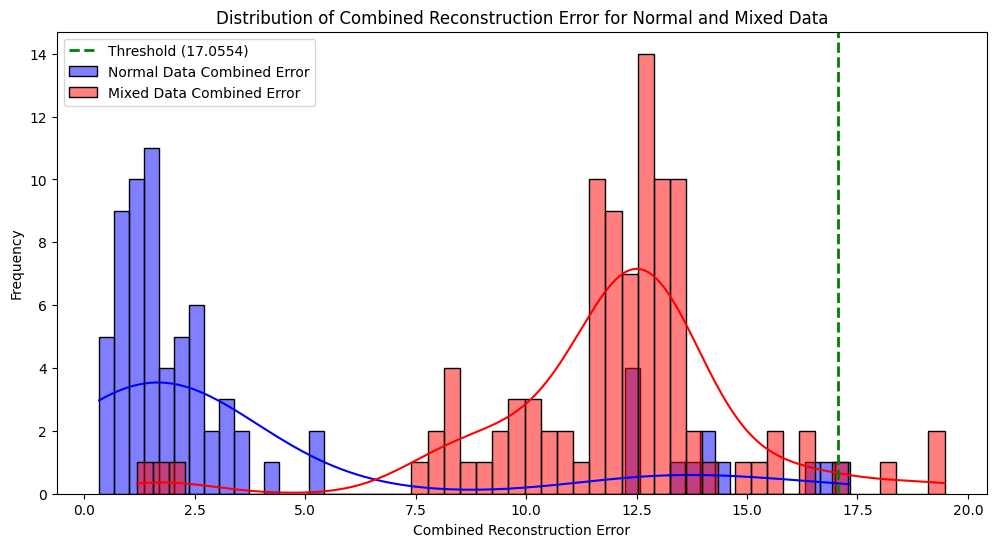

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.histplot(combined_errors_normal, bins=50, kde=True, color='blue', label='Normal Data Combined Error')
sns.histplot(combined_errors_mixed, bins=50, kde=True, color='red', label='Mixed Data Combined Error')
plt.axvline(new_threshold, color='green', linestyle='dashed', linewidth=2, label=f'Threshold ({new_threshold:.4f})')
plt.xlabel('Combined Reconstruction Error')
plt.ylabel('Frequency')
plt.title('Distribution of Combined Reconstruction Error for Normal and Mixed Data')
plt.legend()
plt.show()

In [ ]:
import tensorflow as tf

# Step 1: Make predictions on the normal data
predictions_multi_output_normal = multi_output_model.predict([X_numerical_sequences, X_categories_sequences])

# Separate predictions for numerical and categorical features
predicted_numerical_normal = predictions_multi_output_normal[0]
predicted_categorical_normal = predictions_multi_output_normal[1:]

# Step 2: Calculate Mean Squared Error for numerical features
mse_numerical_normal = np.mean(np.square(predicted_numerical_normal - X_numerical_sequences), axis=(1, 2))

# Step 3: Calculate Sparse Categorical Crossentropy for each categorical feature
# Use a list to store categorical errors
categorical_errors_normal = []
for i, pred_cat_normal in enumerate(predicted_categorical_normal):
    # Ensure true labels for categorical features are of integer type
    true_cat_normal = X_categories_sequences[:, :, i].astype(int)

    # Initialize SparseCategoricalCrossentropy loss function
    scc_loss_fn = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False, reduction=tf.keras.losses.Reduction.NONE)

    # Calculate loss for each time step in the sequence
    # pred_cat_normal shape: (num_sequences, sequence_length, num_classes)
    # true_cat_normal shape: (num_sequences, sequence_length)
    cat_loss_per_timestep = scc_loss_fn(true_cat_normal, pred_cat_normal)

    # Average loss over the sequence length for each sequence
    avg_cat_loss_per_sequence = np.mean(cat_loss_per_timestep, axis=1)
    categorical_errors_normal.append(avg_cat_loss_per_sequence)

# Step 4: Combine the errors. Since no loss_weights were specified during compile,
# Keras sums them with default weight 1.0. So, we'll sum the individual errors.
combined_errors_normal = mse_numerical_normal.copy()
for cat_err in categorical_errors_normal:
    combined_errors_normal += cat_err

# Map combined_errors_normal back to original_normal_df
# Create a temporary DataFrame with original indices and combined_errors_normal
combined_errors_temp_df = pd.DataFrame({'combined_error': combined_errors_normal})

# Add 'original_index' from normal_sequence_info to the temporary DataFrame
# This creates a mapping from sequence error to the original transaction index
sequence_indices_df = pd.DataFrame(normal_sequence_info)
combined_errors_temp_df['original_index'] = sequence_indices_df['original_index']

# Aggregate to find the maximum combined error for each original_index (if multiple sequences end on it)
max_combined_error_per_index_normal = combined_errors_temp_df.groupby('original_index')['combined_error'].max().reset_index()

# Merge this back into the original_normal_df (or a copy of original_normal_df)
# Use original_normal_df from earlier steps if normal_df_with_mse_original is not what's intended
# Assuming original_normal_df is the clean copy of normal data before any transformations

# Ensure original_normal_df_with_mse is a copy to add new columns safely
normal_df_with_combined_error = original_normal_df.copy()
normal_df_with_combined_error = normal_df_with_combined_error.reset_index()
# Rename the 'index' column to 'original_index' before merging for consistency
normal_df_with_combined_error.rename(columns={'index': 'original_index'}, inplace=True)
normal_df_with_combined_error = pd.merge(
    normal_df_with_combined_error,
    max_combined_error_per_index_normal,
    on='original_index',
    how='left'
)
normal_df_with_combined_error.set_index('original_index', inplace=True)
normal_df_with_combined_error.sort_index(inplace=True)

# Step 5: Determine a new anomaly threshold from combined errors
new_threshold = np.percentile(combined_errors_normal, 99)

print("Combined reconstruction error calculated for normal data.")
print(f"New anomaly detection threshold (99th percentile): {new_threshold:.4f}")

print("Normal DataFrame with combined reconstruction error:")
display(normal_df_with_combined_error.head())

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
Combined reconstruction error calculated for normal data.
New anomaly detection threshold (99th percentile): 17.0554
Normal DataFrame with combined reconstruction error:


,station,VIN,time,fuel,pompNo,amount,plate,combined_error
original_index,,,,,,,,
0,a,NAB374448LA000882,1402/09/01 06:01:18,نفت گاز,6,200.0,12الف 003,NaN
1,a,NAB374448LA000882,1402/09/03 18:05:21,نفت گاز,6,200.0,12الف 003,NaN
2,a,NAB374448LA000882,1402/09/10 14:45:31,نفت گاز,6,200.0,12الف 003,16.485981
3,b,NAB374448LA000882,1402/09/11 19:34:08,نفت گاز,6,200.0,12الف 003,17.328145
4,a,NAB374448LA000882,1402/09/20 19:05:29,نفت گاز,6,200.0,12الف 003,16.943931


**Reasoning**:
The previous steps successfully trained the multi-output autoencoder and calculated the combined reconstruction error for the normal dataset, along with a new anomaly threshold. The next logical step is to apply this model to the `mixed_df` (which contains anomalies) to predict anomalies and evaluate the model's performance. This involves preparing the `mixed_df` data consistently with the training data (feature extraction, encoding, scaling), generating sequences, making predictions, calculating combined errors, mapping them back, and then using the new threshold to detect anomalies and evaluate.



In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf

# Make a copy of mixed_df to work with, as previous operations might have modified it
mixed_df_processed = original_mixed_df.copy()

# Step 1: Extract features from the time column (consistent with normal_df preprocessing)
mixed_df_processed['hour'] = mixed_df_processed['time'].dt.hour
mixed_df_processed['day_of_week'] = mixed_df_processed['time'].dt.dayofweek
mixed_df_processed['month'] = mixed_df_processed['time'].dt.month

# Step 2: Encode categorical features using the *same* LabelEncoders fitted on normal_df
# Handle potential new categories in mixed_df by assigning them to a default value or handling them
# A safer approach is to apply the encoder and fill unknown values, e.g., with -1 or a specific value
# For this task, we'll try to transform, and replace unknown with the most frequent category or a new 'unknown' category if possible,
# but simplest for now is to replace with first category seen in normal_df if unseen, or just map

X_categories_mixed_encoded = mixed_df_processed[categorical_features].copy() # Create a copy to avoid SettingWithCopyWarning

for feature in categorical_features:
    if feature in label_encoders:
        le = label_encoders[feature]
        # Map unseen labels to a placeholder value (e.g., the mode of the training feature or a specific 'unknown' integer)
        # For simplicity, if a category is new, it won't be transformed by `le.transform` and will raise an error.
        # Instead, we will use a try-except block or a function to handle unseen labels gracefully.

        # Function to handle unseen labels
        def map_labels(series, encoder):
            known_classes_map = {cls: idx for idx, cls in enumerate(encoder.classes_)}
            # If a label is not known, map it to the index of the first known class or create a new one.
            # Here, we map to 0 (the first class index) for simplicity for unseen labels.
            # A better approach for production would be to expand LabelEncoder or use a dedicated 'unknown' category.
            return series.map(known_classes_map).fillna(0).astype(int) # Fillna with 0 for unknown

        mixed_df_processed[feature] = map_labels(mixed_df_processed[feature], le)
    else:
        # This case should ideally not happen if feature lists are consistent
        print(f"Warning: Encoder for feature '{feature}' not found. Fitting a new one.")
        le = LabelEncoder()
        mixed_df_processed[feature] = le.fit_transform(mixed_df_processed[feature])
        label_encoders[feature] = le

# Step 3: Scale numerical features using the *same* scaler fitted on normal_df
# Ensure the numerical_features list is consistent and contains all relevant features
# Re-create the scaler if it's not available (it should be if previous steps ran)
# The `scaler` was defined in cell bTj11FmkaWrN and `scaler = MinMaxScaler()`

mixed_df_processed[numerical_features] = scaler.transform(mixed_df_processed[numerical_features])

# Step 4: Create sequences for mixed_df (consistent with normal_df sequencing)
X_numerical_sequences_mixed = []
X_categories_sequences_mixed = []
mixed_sequence_info = [] # Store info to map sequences back to original data

for vin, group in mixed_df_processed.groupby('VIN'):
    if len(group) >= sequence_length:
        indices = group.index
        # Extract numerical and categorical data for the current group
        numerical_group = mixed_df_processed.loc[indices, numerical_features].values
        categorical_group = mixed_df_processed.loc[indices, categorical_features].values

        for i in range(len(group) - sequence_length + 1):
            X_numerical_sequences_mixed.append(numerical_group[i:i + sequence_length])
            X_categories_sequences_mixed.append(categorical_group[i:i + sequence_length])
            mixed_sequence_info.append({'original_index': indices[i + sequence_length - 1], 'VIN': vin})

X_numerical_sequences_mixed = np.array(X_numerical_sequences_mixed)
X_categories_sequences_mixed = np.array(X_categories_sequences_mixed)

print('Shape of mixed numerical sequences:', X_numerical_sequences_mixed.shape)
print('Shape of mixed categorical sequences:', X_categories_sequences_mixed.shape)

# Step 5: Make predictions on the mixed data using the trained multi-output model
predictions_multi_output_mixed = multi_output_model.predict([X_numerical_sequences_mixed, X_categories_sequences_mixed])

# Separate predictions for numerical and categorical features
predicted_numerical_mixed = predictions_multi_output_mixed[0]
predicted_categorical_mixed = predictions_multi_output_mixed[1:]

# Step 6: Calculate combined reconstruction error for mixed data
mse_numerical_mixed = np.mean(np.square(predicted_numerical_mixed - X_numerical_sequences_mixed), axis=(1, 2))

categorical_errors_mixed = []
for i, pred_cat_mixed in enumerate(predicted_categorical_mixed):
    true_cat_mixed = X_categories_sequences_mixed[:, :, i].astype(int)
    scc_loss_fn = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False, reduction=tf.keras.losses.Reduction.NONE)
    cat_loss_per_timestep = scc_loss_fn(true_cat_mixed, pred_cat_mixed)
    avg_cat_loss_per_sequence = np.mean(cat_loss_per_timestep, axis=1)
    categorical_errors_mixed.append(avg_cat_loss_per_sequence)

combined_errors_mixed = mse_numerical_mixed.copy()
for cat_err in categorical_errors_mixed:
    combined_errors_mixed += cat_err

# Step 7: Map combined_errors_mixed back to mixed_df1 for anomaly detection
mixed_errors_temp_df = pd.DataFrame({'combined_error': combined_errors_mixed})
sequence_indices_mixed_df = pd.DataFrame(mixed_sequence_info)
mixed_errors_temp_df['original_index'] = sequence_indices_mixed_df['original_index']

max_combined_error_per_index_mixed = mixed_errors_temp_df.groupby('original_index')['combined_error'].max().reset_index()

# Use mixed_df1 as it contains the original 'anomaly' labels
mixed_df_with_combined_error = mixed_df1.copy()
mixed_df_with_combined_error = mixed_df_with_combined_error.reset_index()
mixed_df_with_combined_error.rename(columns={'index': 'original_index'}, inplace=True)
mixed_df_with_combined_error = pd.merge(
    mixed_df_with_combined_error,
    max_combined_error_per_index_mixed,
    on='original_index',
    how='left'
)
mixed_df_with_combined_error.set_index('original_index', inplace=True)
mixed_df_with_combined_error.sort_index(inplace=True)

# Fill NaN values in 'combined_error' for transactions that didn't form a full sequence (e.g., first sequence_length-1 entries)
# with a default value, or a high value if we want them not to be considered normal (depends on anomaly definition)
# For now, let's fill with the mean of combined errors, or 0 if it should be normal
mixed_df_with_combined_error['combined_error'].fillna(combined_errors_mixed.mean(), inplace=True)

# Step 8: Anomaly Detection using the new_threshold
mixed_df_with_combined_error['predicted_anomaly'] = mixed_df_with_combined_error['combined_error'] > new_threshold

# Step 9: Evaluate the model
from sklearn.metrics import confusion_matrix, classification_report

actual_anomalies = mixed_df_with_combined_error['anomaly'].astype(bool)
predicted_anomalies = mixed_df_with_combined_error['predicted_anomaly'].astype(bool)

print("\nEvaluation on Mixed Data:")
print("Confusion Matrix:")
print(confusion_matrix(actual_anomalies, predicted_anomalies))
print("\nClassification Report:")
print(classification_report(actual_anomalies, predicted_anomalies))

print(f"New anomaly threshold: {new_threshold:.4f}")
print("Mixed DataFrame with combined reconstruction error and predicted anomalies (first 5 rows):")
display(mixed_df_with_combined_error.head())


AttributeError: Can only use .dt accessor with datetimelike values

**Reasoning**:
The previous code failed because the 'time' column in `mixed_df_processed` was not converted to datetime objects before attempting to extract time features. I will apply the `convert_jalali_to_datetime` function to ensure the 'time' column is in the correct format.



In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf

# Make a copy of mixed_df to work with, as previous operations might have modified it
mixed_df_processed = original_mixed_df.copy()

# Convert 'time' column to datetime objects using the function defined earlier
mixed_df_processed['time'] = mixed_df_processed['time'].apply(convert_jalali_to_datetime)

# Step 1: Extract features from the time column (consistent with normal_df preprocessing)
mixed_df_processed['hour'] = mixed_df_processed['time'].dt.hour
mixed_df_processed['day_of_week'] = mixed_df_processed['time'].dt.dayofweek
mixed_df_processed['month'] = mixed_df_processed['time'].dt.month

# Step 2: Encode categorical features using the *same* LabelEncoders fitted on normal_df
# Handle potential new categories in mixed_df by assigning them to a default value or handling them
# A safer approach is to apply the encoder and fill unknown values, e.g., with -1 or a specific value
# For this task, we'll try to transform, and replace unknown with the most frequent category or a new 'unknown' category if possible,
# but simplest for now is to replace with first category seen in normal_df if unseen, or just map

X_categories_mixed_encoded = mixed_df_processed[categorical_features].copy() # Create a copy to avoid SettingWithCopyWarning

for feature in categorical_features:
    if feature in label_encoders:
        le = label_encoders[feature]
        # Function to handle unseen labels
        def map_labels(series, encoder):
            known_classes_map = {cls: idx for idx, cls in enumerate(encoder.classes_)}
            # If a label is not known, map it to the index of the first known class or create a new one.
            # Here, we map to 0 (the first class index) for simplicity for unseen labels.
            # A better approach for production would be to expand LabelEncoder or use a dedicated 'unknown' category.
            return series.map(known_classes_map).fillna(0).astype(int) # Fillna with 0 for unknown

        mixed_df_processed[feature] = map_labels(mixed_df_processed[feature], le)
    else:
        # This case should ideally not happen if feature lists are consistent
        print(f"Warning: Encoder for feature '{feature}' not found. Fitting a new one.")
        le = LabelEncoder()
        mixed_df_processed[feature] = le.fit_transform(mixed_df_processed[feature])
        label_encoders[feature] = le

# Step 3: Scale numerical features using the *same* scaler fitted on normal_df
# Ensure the numerical_features list is consistent and contains all relevant features
# Re-create the scaler if it's not available (it should be if previous steps ran)
# The `scaler` was defined in cell bTj11FmkaWrN and `scaler = MinMaxScaler()`

mixed_df_processed[numerical_features] = scaler.transform(mixed_df_processed[numerical_features])

# Step 4: Create sequences for mixed_df (consistent with normal_df sequencing)
X_numerical_sequences_mixed = []
X_categories_sequences_mixed = []
mixed_sequence_info = [] # Store info to map sequences back to original data

for vin, group in mixed_df_processed.groupby('VIN'):
    if len(group) >= sequence_length:
        indices = group.index
        # Extract numerical and categorical data for the current group
        numerical_group = mixed_df_processed.loc[indices, numerical_features].values
        categorical_group = mixed_df_processed.loc[indices, categorical_features].values

        for i in range(len(group) - sequence_length + 1):
            X_numerical_sequences_mixed.append(numerical_group[i:i + sequence_length])
            X_categories_sequences_mixed.append(categorical_group[i:i + sequence_length])
            mixed_sequence_info.append({'original_index': indices[i + sequence_length - 1], 'VIN': vin})

X_numerical_sequences_mixed = np.array(X_numerical_sequences_mixed)
X_categories_sequences_mixed = np.array(X_categories_sequences_mixed)

print('Shape of mixed numerical sequences:', X_numerical_sequences_mixed.shape)
print('Shape of mixed categorical sequences:', X_categories_sequences_mixed.shape)

# Step 5: Make predictions on the mixed data using the trained multi-output model
predictions_multi_output_mixed = multi_output_model.predict([X_numerical_sequences_mixed, X_categories_sequences_mixed])

# Separate predictions for numerical and categorical features
predicted_numerical_mixed = predictions_multi_output_mixed[0]
predicted_categorical_mixed = predictions_multi_output_mixed[1:]

# Step 6: Calculate combined reconstruction error for mixed data
mse_numerical_mixed = np.mean(np.square(predicted_numerical_mixed - X_numerical_sequences_mixed), axis=(1, 2))

categorical_errors_mixed = []
for i, pred_cat_mixed in enumerate(predicted_categorical_mixed):
    true_cat_mixed = X_categories_sequences_mixed[:, :, i].astype(int)
    scc_loss_fn = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False, reduction=tf.keras.losses.Reduction.NONE)
    cat_loss_per_timestep = scc_loss_fn(true_cat_mixed, pred_cat_mixed)
    avg_cat_loss_per_sequence = np.mean(cat_loss_per_timestep, axis=1)
    categorical_errors_mixed.append(avg_cat_loss_per_sequence)

combined_errors_mixed = mse_numerical_mixed.copy()
for cat_err in categorical_errors_mixed:
    combined_errors_mixed += cat_err

# Step 7: Map combined_errors_mixed back to mixed_df1 for anomaly detection
mixed_errors_temp_df = pd.DataFrame({'combined_error': combined_errors_mixed})
sequence_indices_mixed_df = pd.DataFrame(mixed_sequence_info)
mixed_errors_temp_df['original_index'] = sequence_indices_mixed_df['original_index']

max_combined_error_per_index_mixed = mixed_errors_temp_df.groupby('original_index')['combined_error'].max().reset_index()

# Use mixed_df1 as it contains the original 'anomaly' labels
mixed_df_with_combined_error = mixed_df1.copy()
mixed_df_with_combined_error = mixed_df_with_combined_error.reset_index()
mixed_df_with_combined_error.rename(columns={'index': 'original_index'}, inplace=True)
mixed_df_with_combined_error = pd.merge(
    mixed_df_with_combined_error,
    max_combined_error_per_index_mixed,
    on='original_index',
    how='left'
)
mixed_df_with_combined_error.set_index('original_index', inplace=True)
mixed_df_with_combined_error.sort_index(inplace=True)

# Fill NaN values in 'combined_error' for transactions that didn't form a full sequence (e.g., first sequence_length-1 entries)
# with a default value, or a high value if we want them not to be considered normal (depends on anomaly definition)
# For now, let's fill with the mean of combined errors, or 0 if it should be normal
mixed_df_with_combined_error['combined_error'].fillna(combined_errors_mixed.mean(), inplace=True)

# Step 8: Anomaly Detection using the new_threshold
mixed_df_with_combined_error['predicted_anomaly'] = mixed_df_with_combined_error['combined_error'] > new_threshold

# Step 9: Evaluate the model
from sklearn.metrics import confusion_matrix, classification_report

actual_anomalies = mixed_df_with_combined_error['anomaly'].astype(bool)
predicted_anomalies = mixed_df_with_combined_error['predicted_anomaly'].astype(bool)

print("\nEvaluation on Mixed Data:")
print("Confusion Matrix:")
print(confusion_matrix(actual_anomalies, predicted_anomalies))
print("\nClassification Report:")
print(classification_report(actual_anomalies, predicted_anomalies))

print(f"New anomaly threshold: {new_threshold:.4f}")
print("Mixed DataFrame with combined reconstruction error and predicted anomalies (first 5 rows):")
display(mixed_df_with_combined_error.head())

Shape of mixed numerical sequences: (98, 3, 4)
Shape of mixed categorical sequences: (98, 3, 5)
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 


/tmp/ipython-input-3628615230.py:118: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  mixed_df_with_combined_error['combined_error'].fillna(combined_errors_mixed.mean(), inplace=True)



Evaluation on Mixed Data:
Confusion Matrix:
[[26  0]
 [74  4]]

Classification Report:
              precision    recall  f1-score   support

       False       0.26      1.00      0.41        26
        True       1.00      0.05      0.10        78

    accuracy                           0.29       104
   macro avg       0.63      0.53      0.26       104
weighted avg       0.82      0.29      0.18       104

New anomaly threshold: 17.0554
Mixed DataFrame with combined reconstruction error and predicted anomalies (first 5 rows):


,station,VIN,time,fuel,pompNo,amount,plate,anomaly,anomaly_cat,combined_error,predicted_anomaly
original_index,,,,,,,,,,,
0,b,IRADX8810BG867727,1402/09/26 09:57:53,بنزین معمولی,1,10.0,12الف 060,1,تكرار,11.980980,False
1,b,IRADX8810BG867727,1402/09/26 19:39:02,بنزین معمولی,1,10.0,12الف 060,1,تكرار,11.980980,False
2,b,IRADX8810BG867727,1402/09/26 19:41:11,بنزین معمولی,1,10.0,12الف 060,1,تكرار,10.445304,False
3,c,IREB9394S7I443394,1402/09/09 13:24:15,نفت گاز,6,150.0,12الف 062,1,تكرار,18.036792,True
4,c,IREB9394S7I443394,1402/09/10 19:15:53,نفت گاز,6,150.0,12الف 062,1,تكرار,12.747961,False
